In [153]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import joblib
import json
from datetime import datetime


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")









✅ Libraries imported successfully!


In [154]:
df = pd.read_csv('../data/raw.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10 columns

Dataset shape: (1460, 81)
Columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities']...


In [155]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [157]:
# Statistical summary of target variable
print("SalePrice Statistics:")
print(f"Count: {df['SalePrice'].count():,}")
print(f"Mean: ${df['SalePrice'].mean():,.0f}")
print(f"Median: ${df['SalePrice'].median():,.0f}")
print(f"Std Dev: ${df['SalePrice'].std():,.0f}")
print(f"Min: ${df['SalePrice'].min():,.0f}")
print(f"Max: ${df['SalePrice'].max():,.0f}")

SalePrice Statistics:
Count: 1,460
Mean: $180,921
Median: $163,000
Std Dev: $79,443
Min: $34,900
Max: $755,000


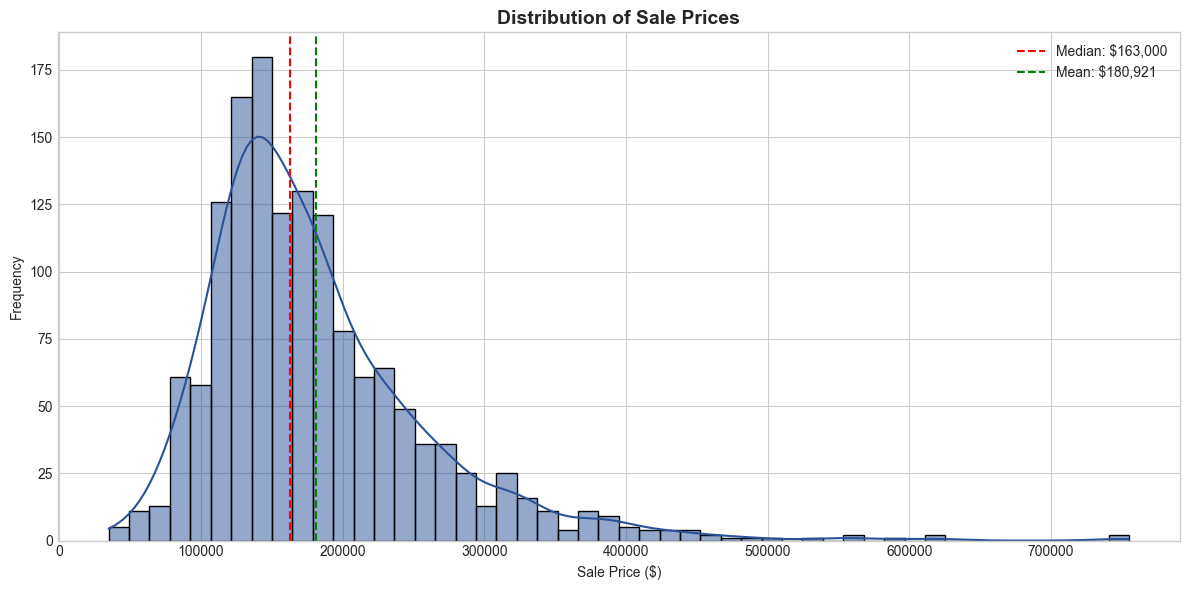

📊 Chart 1: Sale prices are right-skewed.


In [158]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
sns.histplot(df['SalePrice'], kde=True, bins=50, color='#2a5298')
plt.title('Distribution of Sale Prices', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.axvline(df['SalePrice'].median(), color='red', linestyle='--', label=f"Median: ${df['SalePrice'].median():,.0f}")
plt.axvline(df['SalePrice'].mean(), color='green', linestyle='--', label=f"Mean: ${df['SalePrice'].mean():,.0f}")
plt.legend()

plt.tight_layout()
plt.show()

print("📊 Chart 1: Sale prices are right-skewed.")

In [159]:
selected_features = [
    'LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'Street',
    'GrLivArea', 'FullBath', 'BedroomAbvGr', 'GarageCars',
    'Neighborhood', 'HouseStyle', 'SalePrice'
]

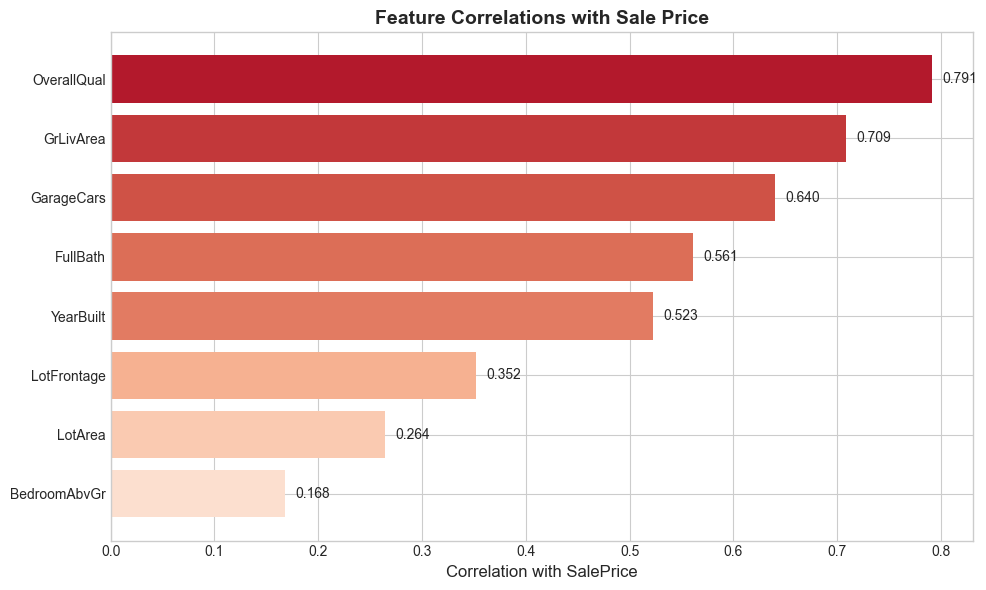

📊 Chart 2: Strongest predictors of price:
   OverallQual: 0.791
   GrLivArea: 0.709
   GarageCars: 0.640
   FullBath: 0.561
   YearBuilt: 0.523


In [160]:
# Select only numeric features + target for simple correlation
numeric_features = ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 
                    'GrLivArea', 'FullBath', 'BedroomAbvGr', 'GarageCars', 'SalePrice']

# Calculate correlations
corr_df = df[numeric_features].corr()
correlations = corr_df['SalePrice'].drop('SalePrice').sort_values(ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
colors = plt.cm.RdBu_r((correlations.values + 1) / 2)  # Color by correlation strength
bars = plt.barh(correlations.index, correlations.values, color=colors)

# Add value labels
for bar, val in zip(bars, correlations.values):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=10)

plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Correlation with SalePrice', fontsize=12)
plt.title('Feature Correlations with Sale Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Chart 2: Strongest predictors of price:")
for feature, corr in correlations.abs().sort_values(ascending=False).head(5).items():
    print(f"   {feature}: {corr:.3f}")

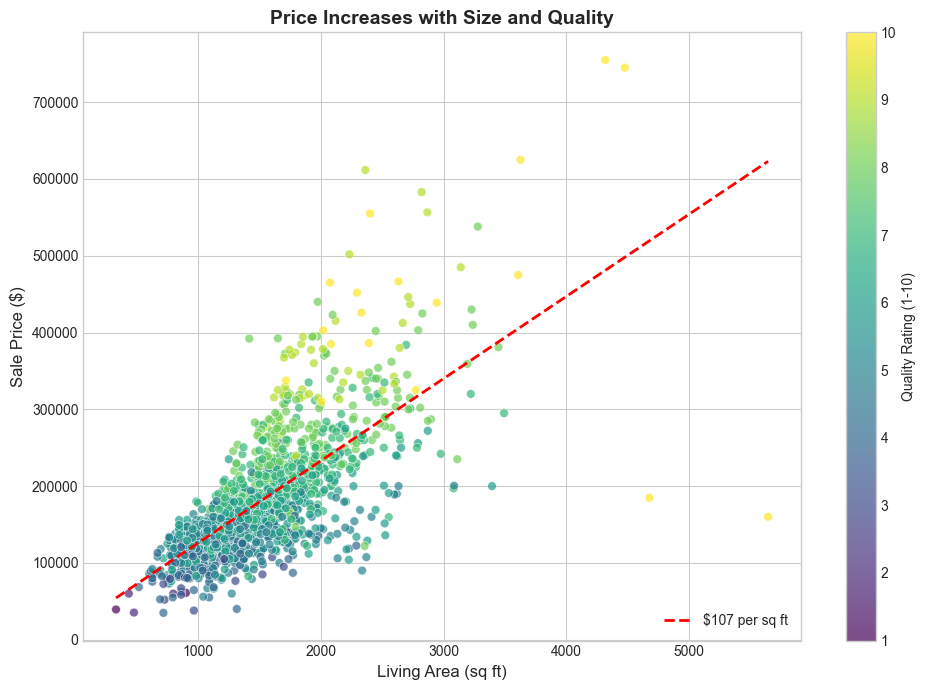

📊 Chart 3: Living area correlation with price: r = 0.709


In [161]:
# ## 🏡 5. Chart 3: Price vs Living Area

# %%
plt.figure(figsize=(10, 7))

# Simple scatter with colorbar
scatter = plt.scatter(df['GrLivArea'], df['SalePrice'],
                     c=df['OverallQual'],
                     cmap='viridis',
                     alpha=0.7,
                     s=40,
                     edgecolors='white',
                     linewidth=0.5)

# Trend line
z = np.polyfit(df['GrLivArea'].dropna(), df['SalePrice'].dropna(), 1)
p = np.poly1d(z)
x_trend = np.linspace(df['GrLivArea'].min(), df['GrLivArea'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'${z[0]:.0f} per sq ft')

plt.colorbar(scatter, label='Quality Rating (1-10)')
plt.xlabel('Living Area (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('Price Increases with Size and Quality', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

correlation = df['GrLivArea'].corr(df['SalePrice'])
print(f"📊 Chart 3: Living area correlation with price: r = {correlation:.3f}")

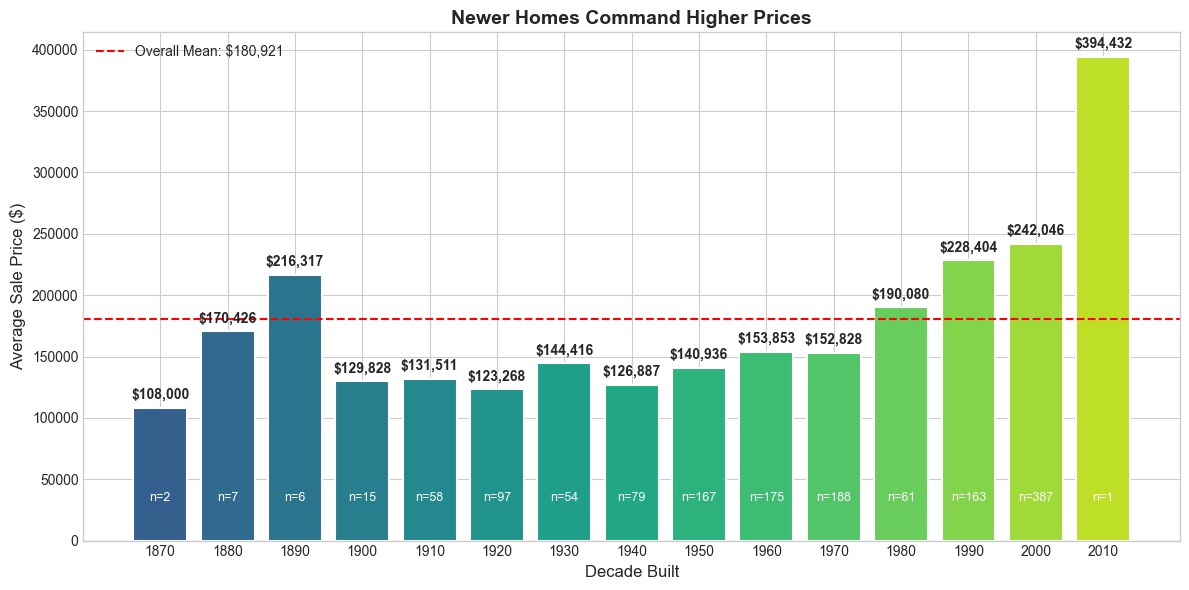

📊 Chart 4: Clear upward trend in prices for newer construction
   Pre-1950 average: $132,269
   Post-2000 average: $242,439
   Premium for new homes: +83%


In [162]:
df['Decade'] = (df['YearBuilt'] // 10) * 10
decade_prices = df.groupby('Decade')['SalePrice'].agg(['mean', 'count']).reset_index()

plt.figure(figsize=(12, 6))

# Bar plot for average price by decade
bars = plt.bar(decade_prices['Decade'].astype(str), decade_prices['mean'], 
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(decade_prices))),
               edgecolor='white', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, decade_prices['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add count labels
for bar, count in zip(bars, decade_prices['count']):
    plt.text(bar.get_x() + bar.get_width()/2, 30000,
             f'n={count}', ha='center', va='bottom', fontsize=9, color='white')

plt.axhline(y=df['SalePrice'].mean(), color='red', linestyle='--', 
            linewidth=1.5, label=f'Overall Mean: ${df["SalePrice"].mean():,.0f}')

plt.xlabel('Decade Built', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)
plt.title('Newer Homes Command Higher Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("📊 Chart 4: Clear upward trend in prices for newer construction")
print(f"   Pre-1950 average: ${df[df['YearBuilt']<1950]['SalePrice'].mean():,.0f}")
print(f"   Post-2000 average: ${df[df['YearBuilt']>=2000]['SalePrice'].mean():,.0f}")
print(f"   Premium for new homes: +{((df[df['YearBuilt']>=2000]['SalePrice'].mean() / df[df['YearBuilt']<1950]['SalePrice'].mean() - 1) * 100):.0f}%")

In [163]:
FEATURES = [
    "LotFrontage", "LotArea", "OverallQual", "YearBuilt", "Street",
    "GrLivArea", "FullBath", "BedroomAbvGr", "GarageCars",
    "Neighborhood", "HouseStyle"
]
TARGET = "SalePrice"

NUM_FEATURES = [
    "LotFrontage", "LotArea", "OverallQual", "YearBuilt",
    "GrLivArea", "FullBath", "BedroomAbvGr", "GarageCars"
]

CAT_FEATURES = ["Neighborhood", "HouseStyle", "Street"]

In [164]:
df_model = df[FEATURES + [TARGET]].dropna(subset=[TARGET])
X = df_model[FEATURES]
y = df_model[TARGET]

In [165]:
# Split data (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {len(X_train):,} samples")
print(f"Validation set: {len(X_val):,} samples")
print(f"Test set: {len(X_test):,} samples")

Training set: 876 samples
Validation set: 292 samples
Test set: 292 samples


In [166]:
# Numeric pipeline
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=False,drop="first"))
])

In [167]:
# Full preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUM_FEATURES),
        ("cat", categorical_pipeline, CAT_FEATURES),
    ],
    remainder="drop"
)

print("✅ Preprocessing pipeline created!")

✅ Preprocessing pipeline created!


In [168]:
# Define models
models = {
    "GradientBoosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42))
    ]),
    
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "HistGradientBoosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_depth=5,
            learning_rate=0.05,
            max_iter=300,
            min_samples_leaf=10,
            random_state=42
        ))
    ])
}


In [169]:
# Train and evaluate
results = []

for name, pipeline in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    
    results.append({
        "Model": name,
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "Train MAE": train_mae,
        "Val MAE": val_mae,
        "Train R²": train_r2,
        "Val R²": val_r2,
        "CV R² (mean)": cv_scores.mean(),
        "CV R² (std)": cv_scores.std(),
        "Pipeline": pipeline
    })
    
    print(f"Train RMSE: ${train_rmse:,.0f}")
    print(f"Val RMSE:   ${val_rmse:,.0f}")
    print(f"Train R²:   {train_r2:.3f}")
    print(f"Val R²:     {val_r2:.3f}")
    print(f"CV R²:      {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


Training GradientBoosting...


g:\Real Estate Agent\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Train RMSE: $10,324
Val RMSE:   $41,672
Train R²:   0.981
Val R²:     0.816
CV R²:      0.795 (+/- 0.078)

Training RandomForest...


g:\Real Estate Agent\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Train RMSE: $30,774
Val RMSE:   $47,478
Train R²:   0.833
Val R²:     0.761
CV R²:      0.767 (+/- 0.039)

Training HistGradientBoosting...
Train RMSE: $15,850
Val RMSE:   $38,593
Train R²:   0.956
Val R²:     0.842
CV R²:      0.811 (+/- 0.046)


g:\Real Estate Agent\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



MODEL COMPARISON SUMMARY


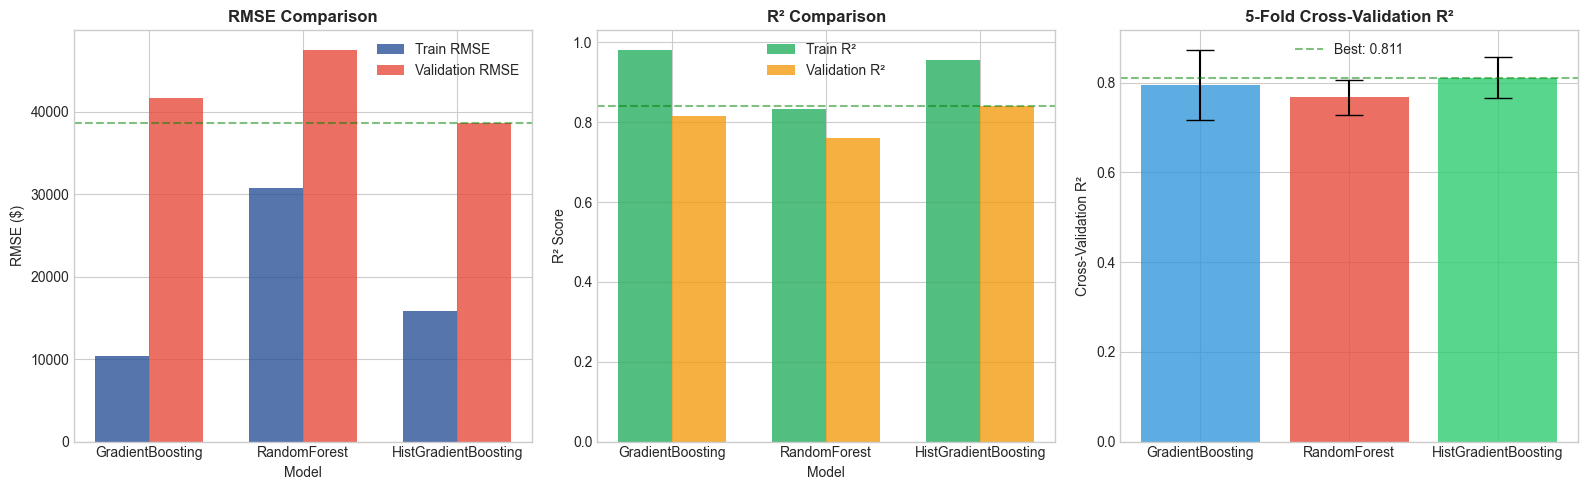

In [170]:
# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.drop('Pipeline', axis=1)

# Display results
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
results_df.style.background_gradient(cmap='RdYlGn', subset=['Val R²', 'CV R² (mean)'])

# %%
# Visualization of model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE Comparison
models_names = results_df['Model'].tolist()
val_rmse = results_df['Val RMSE'].tolist()
train_rmse = results_df['Train RMSE'].tolist()

x = np.arange(len(models_names))
width = 0.35

axes[0].bar(x - width/2, train_rmse, width, label='Train RMSE', color='#2a5298', alpha=0.8)
axes[0].bar(x + width/2, val_rmse, width, label='Validation RMSE', color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names)
axes[0].legend()
axes[0].axhline(y=min(val_rmse), color='green', linestyle='--', alpha=0.5, label=f'Best: ${min(val_rmse):,.0f}')

# R² Comparison
val_r2 = results_df['Val R²'].tolist()
train_r2 = results_df['Train R²'].tolist()

axes[1].bar(x - width/2, train_r2, width, label='Train R²', color='#27ae60', alpha=0.8)
axes[1].bar(x + width/2, val_r2, width, label='Validation R²', color='#f39c12', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Comparison', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_names)
axes[1].legend()
axes[1].axhline(y=max(val_r2), color='green', linestyle='--', alpha=0.5, label=f'Best: {max(val_r2):.3f}')

# Cross-validation R²
cv_means = results_df['CV R² (mean)'].tolist()
cv_stds = results_df['CV R² (std)'].tolist()

bars = axes[2].bar(models_names, cv_means, yerr=cv_stds, capsize=10, 
                   color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
axes[2].set_ylabel('Cross-Validation R²')
axes[2].set_title('5-Fold Cross-Validation R²', fontweight='bold')
axes[2].axhline(y=max(cv_means), color='green', linestyle='--', alpha=0.5, label=f'Best: {max(cv_means):.3f}')
axes[2].legend()

plt.tight_layout()
plt.show()

In [171]:
# Find best model
best_idx = results_df['Val RMSE'].idxmin()
best_model_name = results_df.loc[best_idx, 'Model']
best_pipeline = results[best_idx]['Pipeline']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Validation RMSE: ${results_df.loc[best_idx, 'Val RMSE']:,.0f}")
print(f"   Validation R²: {results_df.loc[best_idx, 'Val R²']:.3f}")

# Retrain on combined train+val for final test evaluation
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

print(f"\nRetraining {best_model_name} on full training data ({len(X_train_full):,} samples)...")
best_pipeline.fit(X_train_full, y_train_full)

# Evaluate on test set
y_test_pred = best_pipeline.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "="*50)
print("FINAL TEST SET PERFORMANCE")
print("="*50)
print(f"Test RMSE: ${test_rmse:,.0f}")
print(f"Test MAE:  ${test_mae:,.0f}")
print(f"Test R²:   {test_r2:.3f}")



🏆 Best Model: HistGradientBoosting
   Validation RMSE: $38,593
   Validation R²: 0.842

Retraining HistGradientBoosting on full training data (1,168 samples)...



FINAL TEST SET PERFORMANCE
Test RMSE: $28,511
Test MAE:  $19,178
Test R²:   0.834


Computing permutation importance for HistGradientBoosting...


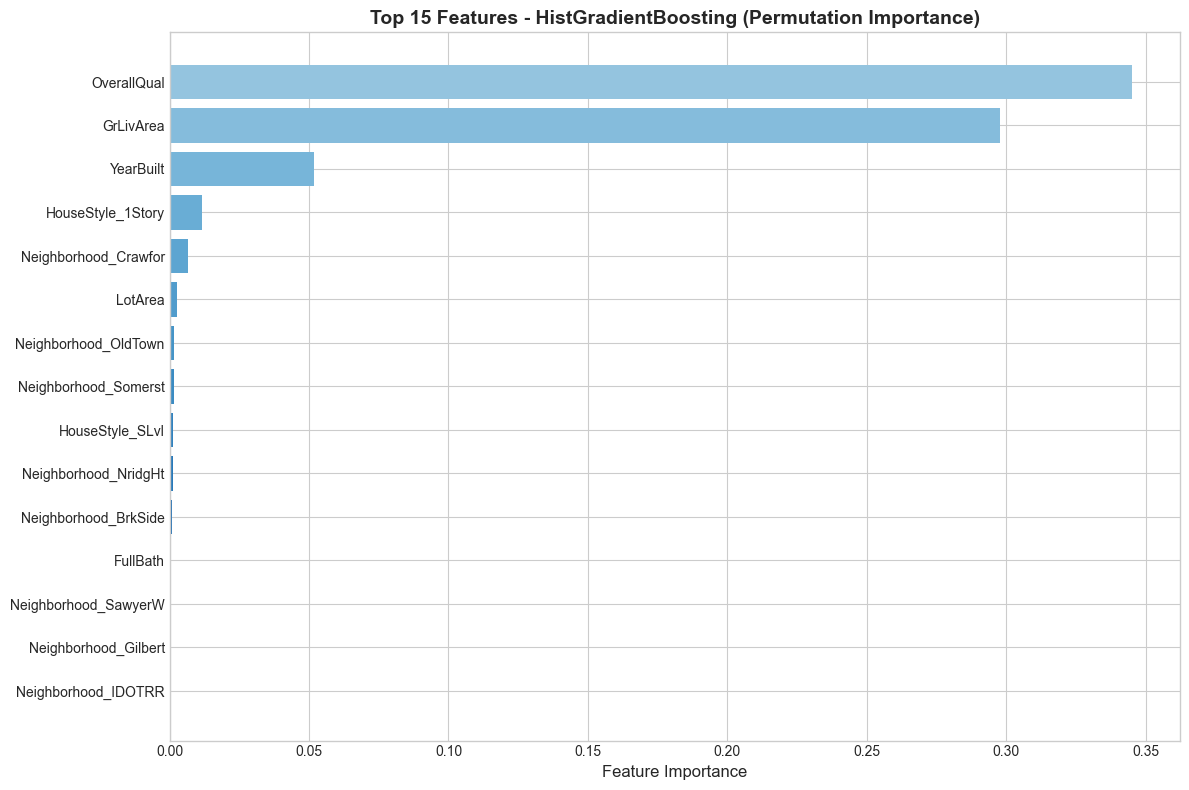


📊 Top 10 Most Important Features (HistGradientBoosting):
   1. OverallQual                    0.3451
   2. GrLivArea                      0.2978
   3. YearBuilt                      0.0519
   4. HouseStyle_1Story              0.0116
   5. Neighborhood_Crawfor           0.0067
   6. LotArea                        0.0025
   7. Neighborhood_OldTown           0.0015
   8. Neighborhood_Somerst           0.0014
   9. HouseStyle_SLvl                0.0013
   10. Neighborhood_NridgHt           0.0012


In [172]:
# %% [markdown]
# ## 📈 12. Feature Importance

# %%
# Get the actual model from the pipeline
model = best_pipeline.named_steps['model']

# Different models have different ways to access feature importance
if best_model_name == 'HistGradientBoosting':
    # HistGradientBoosting uses a different method
    # We need to compute permutation importance instead
    from sklearn.inspection import permutation_importance
    
    print("Computing permutation importance for HistGradientBoosting...")
    
    # Fit preprocessor
    best_pipeline[0].fit(X_train_full)
    X_processed = best_pipeline[0].transform(X_test)
    
    # Compute permutation importance
    perm_importance = permutation_importance(
        best_pipeline.named_steps['model'], 
        X_processed, 
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )
    
    importances = perm_importance.importances_mean
    
    # Get feature names
    num_features = NUM_FEATURES.copy()
    cat_features = best_pipeline[0].named_transformers_['cat'].get_feature_names_out(CAT_FEATURES)
    all_features = list(num_features) + list(cat_features)
    
elif best_model_name in ['GradientBoosting', 'RandomForest']:
    # These models have feature_importances_
    importances = model.feature_importances_
    
    # Get feature names
    best_pipeline[0].fit(X_train_full)
    num_features = NUM_FEATURES.copy()
    cat_features = best_pipeline[0].named_transformers_['cat'].get_feature_names_out(CAT_FEATURES)
    all_features = list(num_features) + list(cat_features)
    
else:
    print(f"❌ Feature importance not available for {best_model_name}")
    importances = None

# Plot if we have importances
if importances is not None:
    # Match lengths
    min_len = min(len(all_features), len(importances))
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': all_features[:min_len],
        'Importance': importances[:min_len]
    }).sort_values('Importance', ascending=False).head(15)
    
    # Plot
    plt.figure(figsize=(12, 8))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importance_df)))
    bars = plt.barh(range(len(importance_df)), importance_df['Importance'], color=colors)
    plt.yticks(range(len(importance_df)), importance_df['Feature'])
    plt.xlabel('Feature Importance', fontsize=12)
    
    if best_model_name == 'HistGradientBoosting':
        plt.title(f'Top 15 Features - {best_model_name} (Permutation Importance)', fontsize=14, fontweight='bold')
    else:
        plt.title(f'Top 15 Features - {best_model_name} (Gini Importance)', fontsize=14, fontweight='bold')
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Top 10 Most Important Features ({best_model_name}):")
    for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
        print(f"   {i}. {row['Feature']:<30} {row['Importance']:.4f}")

In [173]:
# Save the best model pipeline
# joblib.dump(best_pipeline, '../ml/best_model.pkl')
print("✅ Model saved to '../ml/best_model.pkl'")

# Save training statistics
train_stats = {
    "median_price": float(y_train_full.median()),
    "mean_price": float(y_train_full.mean()),
    "price_std": float(y_train_full.std()),
    "price_range": [float(y_train_full.min()), float(y_train_full.max())],
    "sample_count": len(y_train_full),
    "best_model": best_model_name,
    "test_rmse": float(test_rmse),
    "test_mae": float(test_mae),
    "test_r2": float(test_r2),
    "training_date": datetime.now().isoformat(),
    "features_used": FEATURES
}

# with open('../ml/training_stats.json', 'w') as f:
#     json.dump(train_stats, f, indent=2)

print("✅ Training statistics saved to '../ml/training_stats.json'")

# %%
# Display final summary
print("\n" + "="*70)
print("🎉 TRAINING COMPLETE - FINAL SUMMARY")
print("="*70)
print(f"Best Model:        {best_model_name}")
print(f"Test RMSE:         ${test_rmse:,.0f}")
print(f"Test MAE:          ${test_mae:,.0f}")
print(f"Test R²:           {test_r2:.3f}")
print(f"Training Samples:  {len(y_train_full):,}")
print(f"Features Used:     {len(FEATURES)}")
print("="*70)


✅ Model saved to '../ml/best_model.pkl'
✅ Training statistics saved to '../ml/training_stats.json'

🎉 TRAINING COMPLETE - FINAL SUMMARY
Best Model:        HistGradientBoosting
Test RMSE:         $28,511
Test MAE:          $19,178
Test R²:           0.834
Training Samples:  1,168
Features Used:     11
